# Tutorial 1 using Unit Commitment Example

This tutorial shows the different commands for using [GemsPy python package](https://gemspy.readthedocs.io/en/latest/) for modeling and simulating an Unit Commitment problem.

We use in this tutorial the reference library of models called [antares-legacy-models](https://github.com/AntaresSimulatorTeam/GEMS/blob/main/libraries/antares_legacy_models.yml)

## Installation of GemsPy

In [1]:
pip install gemspy matplotlib --quiet

Note: you may need to restart the kernel to use updated packages.


## Create a simple system composed of an area with load

### Step 1: Configure an Area

In the library of models used here, an area is a component representing an energy balance constraint ; several types of components (production, load, storage, links...) might be connected to it. We'll create an area with spillage cost and unsupplied energy cost parameters.

In [ ]:
from gems.study.parsing import InputComponent, InputComponentParameter, InputSystem
from gems.model.parsing import parse_yaml_library
from gems.model.resolve_library import resolve_library
from pathlib import Path

# Set tutorial directory structure
study_name = "Tutorial_Unit_Commitment_with_GemsPy"

base_path = Path.cwd()
library_folder = base_path / study_name
library_file = next(library_folder.glob("*.yml")).name

series_folder = base_path / study_name

# Read library file containing the models
print("LIBRARY READING")
print("\tLibrary path:", library_file)

with open(Path(library_folder, library_file)) as lib_file:
    input_libraries = [parse_yaml_library(lib_file)]
    library_name = input_libraries[0].id
    print("\tLibrary loaded:", library_name)

result_lib = resolve_library(input_libraries)

print("COMPONENTS DEFINITION")
components = []

# Add an area component with spillage and ENS costs
components.append(
    InputComponent(
        id="my_area",
        model=f"{library_name}.area",
        parameters=[
            InputComponentParameter(
                id="spillage_cost",
                time_dependent=False,
                scenario_dependent=False,
                value=1000),
            InputComponentParameter(
                id="ens_cost",
                time_dependent=False,
                scenario_dependent=False,
                value=10000),
        ],
    )
)

# Add a load component with load data from a data series
components.append(
    InputComponent(
        id="load",
        model=f"{library_name}.load",
        parameters=[
            InputComponentParameter(
                id="load",
                time_dependent=True,
                scenario_dependent=True,
                value="load"),
        ],
    )
)
print("\tComponents defined:\n\t", [comp.id for comp in components])

print("INPUT SYSTEM CREATION")
input_system = InputSystem(
            id = "my_system",
            model_libraries=library_name,
            components=components,
        )
print("\tInput system created")

# Uncomment the following line to print the input system
# print("\tThe following input system has been created :")
# print(input_system)

LIBRARY READING
	Library path: tuto_antares_legacy_models.yml
	Library loaded: antares_legacy_models
COMPONENTS DEFINITION
	Components defined:
 ['my_area', 'load']
INPUT SYSTEM CREATION
	Input system created


### Step 2: Configure the Generator (1 unit of 100 MW)

Now we add a thermal generator to the area. This generator will have:
- 1 unit with a maximum capacity of 100 MW
- Generation cost of 50 €/MWh

In [ ]:
print("NEW COMPONENT DEFINITION")
# Add a thermal generator component with technical and economic parameters

components.append(
    InputComponent(
        id="thermal_gen",
        model=f"{library_name}.thermal",
        parameters=[
            InputComponentParameter(id="p_min_unit", time_dependent=False, scenario_dependent=False, value=0),
            InputComponentParameter(id="p_max_unit", time_dependent=False, scenario_dependent=False, value=100),
            InputComponentParameter(id="p_max_cluster", time_dependent=False, scenario_dependent=False, value=100),
            InputComponentParameter(id="generation_cost", time_dependent=False, scenario_dependent=False, value=50),
            InputComponentParameter(id="startup_cost", time_dependent=False, scenario_dependent=False, value=0),
            InputComponentParameter(id="fixed_cost", time_dependent=False, scenario_dependent=False, value=0),
            InputComponentParameter(id="d_min_up", time_dependent=False, scenario_dependent=False, value=1),
            InputComponentParameter(id="d_min_down", time_dependent=False, scenario_dependent=False, value=1),
            InputComponentParameter(id="unit_count", time_dependent=False, scenario_dependent=False, value=1),
            InputComponentParameter(id="spinning", time_dependent=False, scenario_dependent=False, value=0),
            InputComponentParameter(id="minimum_generation_modulation", time_dependent=False, scenario_dependent=False, value=0),
        ],
    )
)


print("\tComponents defined:\n\t", [comp.id for comp in components])

print("INPUT SYSTEM CREATION")
input_system = InputSystem(
            id = "my_system",
            model_libraries=library_name,
            components=components,
        )
print("\tInput system created")


# Uncomment the following lines to print the input system
# print("\tThe following input system has been created :")
# print(input_system)

## Step 3 : Configure the port connection

Then, we interconnect the two components by configuring the ports connection

In [4]:
from gems.study.parsing import InputPortConnections

print("CONNECTIONS DEFINITION")

# Initialize connections list
connections = []

# Add connections between the area and the thermal generator

connections.append(
    InputPortConnections(
        component1="my_area",
        port1="balance_port",
        component2="thermal_gen",
        port2="balance_port",
    )
)


# Add connection between the area and the load
connections.append(
    InputPortConnections(
        component1="my_area",
        port1="balance_port",
        component2="load",
        port2="balance_port",
    )
)


print("\tConnections defined:")
for conn in connections:
    print(f"\t\t{conn.component1}:{conn.port1} <-> {conn.component2}:{conn.port2}")

input_system = InputSystem(
            components=components,
            connections=connections,
        )

# Uncomment the following lines to print the input system
# print("\tThe following input system has been created :")
# print(input_system)



CONNECTIONS DEFINITION
	Connections defined:
		my_area:balance_port <-> thermal_gen:balance_port
		my_area:balance_port <-> load:balance_port


## Step 4 : Run the study and Graph results

In [5]:
from gems.simulation.optimization import (
    TimeBlock,
    build_problem,
)
from gems.study.resolve_components import (
    build_data_base,
    build_network,
    resolve_system
)
from gems.simulation.output_values import OutputValues

print("OPTIMIZATION PROBLEM BUILDING")
# Set optimization parameters
ScenarioNumber = 1 # first scenario
TimeSpan = 7*24 # one week with hourly time steps
result_lib = resolve_library(input_libraries)
components_input = resolve_system(input_system, result_lib)
database = build_data_base(input_system, Path(series_folder))

network = build_network(components_input)
problem = build_problem(
    network,
    database,
    TimeBlock(1, [i for i in range(0, TimeSpan)]),
    ScenarioNumber,
)

print("\t✓ Optimization problem built successfully")

print("SOLVING OPTIMIZATION PROBLEM")
try:
    status = problem.solver.Solve()
    objective_value = problem.solver.Objective().Value()
    print("\t✓ Optimization problem solved successfully")
    results = OutputValues(problem)
    print("\t✓ Results extracted successfully")
except Exception as e:
    print(f"Error solving optimization problem: {e}")
    raise e


# Printing results
objective_value = results.problem.solver.Objective().Value()
print(f"\t✓ Objective value: {objective_value}")

# Uncomment the following line to print the whole results
# print("\n","="*15," RESULTS ","="*15)
# print(results)

OPTIMIZATION PROBLEM BUILDING
	✓ Optimization problem built successfully
SOLVING OPTIMIZATION PROBLEM
	✓ Optimization problem solved successfully
	✓ Results extracted successfully
	✓ Objective value: 2952000.0


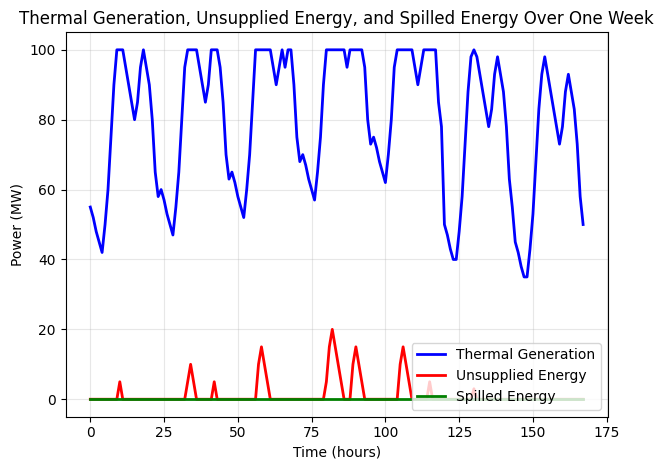

In [6]:
from gems.study.data import TimeScenarioIndex
import matplotlib.pyplot as plt

# Extract generation and nb_units_on data from results (which contains the solved values)
thermal_component = results.component("thermal_gen")
thermal_gen_data = thermal_component.var("generation")
unsupply_data = results.component("my_area").var("unsupplied_energy")
spilled_data = results.component("my_area").var("spillage") 

# Convert to lists using TimeScenarioIndex - use .get() to handle missing keys
thermal_gen_values = [thermal_gen_data._value.get(TimeScenarioIndex(i, 0), 0) for i in range(TimeSpan)]
unsupply_values = [unsupply_data._value.get(TimeScenarioIndex(i, 0), 0) for i in range(TimeSpan)]
spilled_values = [spilled_data._value.get(TimeScenarioIndex(i, 0), 0) for i in range(TimeSpan)]

# Plot Thermal generation and Unsupplied energy over time
plt.plot(thermal_gen_values, linewidth=2, markersize=4, color='blue', label='Thermal Generation')
plt.plot(unsupply_values, linewidth=2, markersize=4, color='red', label='Unsupplied Energy')
plt.plot(spilled_values, linewidth=2, markersize=4, color='green', label='Spilled Energy')
plt.xlabel('Time (hours)')
plt.ylabel('Power (MW)')
plt.title('Thermal Generation, Unsupplied Energy, and Spilled Energy Over One Week')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In these results, it's easy to see that the area has unsuplied energy while the load is above the 100MW threshold of thermal power generation.

In the next section, a wind farm and a solar farm are interconnected to the are for supply it enough energy.

# Add Variable Renewable Energies in the system

## Step 1 : Creation of components 

In this section, the *wind_farm* and *solar_farm* components are added to our system

- The *wind_farm* has a variable power generation between **0 and 60 MW**
- The *solar_farm* has a variable power generation between **0 and 40 MW**

In [ ]:
print("NEW COMPONENTS DEFINITION")

# Add wind farm component with wind generation data from a data series
components.append(
    InputComponent(
        id="wind_farm",
        model=f"{library_name}.renewable",
        parameters=[
            InputComponentParameter(id="nominal_capacity", time_dependent=False, scenario_dependent=False, value=60),
            InputComponentParameter(id="unit_count", time_dependent=False, scenario_dependent=False, value=1),
            InputComponentParameter(id="generation", time_dependent=True, scenario_dependent=True, value="wind"),
        ],              
    )
)

# Add connection between the area and the wind farm
connections.append(
    InputPortConnections(
        component1="my_area",
        port1="balance_port",
        component2="wind_farm",
        port2="balance_port",
    )
)

# Add solar farm component with solar generation data from a data series
components.append(
    InputComponent(
        id="solar_farm",
        model=f"{library_name}.renewable",
        parameters=[
            InputComponentParameter(id="nominal_capacity", time_dependent=False, scenario_dependent=False, value=40),
            InputComponentParameter(id="unit_count", time_dependent=False, scenario_dependent=False, value=1),
            InputComponentParameter(id="generation", time_dependent=True, scenario_dependent=True, value="solar"),
        ],              
    )
)
print("\tComponents defined:\n\t", [comp.id for comp in components])

print("CONNECTIONS DEFINITION")
# Add connection between the area and the solar farm
connections.append(
    InputPortConnections(
        component1="my_area",
        port1="balance_port",
        component2="solar_farm",
        port2="balance_port",
    )
)

print("\tConnections defined:")
for conn in connections:
    print(f"\t\t{conn.component1}:{conn.port1} <-> {conn.component2}:{conn.port2}")

input_system = InputSystem(
    id = "my_system",
    components=components,
    connections=connections,
    )

# Uncomment the following lines to print the input system
# print("\tThe following input system has been created :")
# print(input_system)

NEW COMPONENTS DEFINITION
	Components defined:
 ['my_area', 'load', 'thermal_gen', 'wind_farm', 'solar_farm']
CONNECTIONS DEFINITION
	Connections defined:
		my_area:balance_port <-> thermal_gen:balance_port
		my_area:balance_port <-> load:balance_port
		my_area:balance_port <-> wind_farm:balance_port
		my_area:balance_port <-> solar_farm:balance_port


## Step 2 : Results visualization

In [8]:
print("OPTIMIZATION PROBLEM BUILDING")

result_lib = resolve_library(input_libraries)
components_input = resolve_system(input_system, result_lib)
database = build_data_base(input_system, Path(series_folder))

network = build_network(components_input)
problem = build_problem(
    network,
    database,
    TimeBlock(1, [i for i in range(0, TimeSpan)]),
    ScenarioNumber,
)


print("\t✓ Optimization problem built successfully")

print("SOLVING OPTIMIZATION PROBLEM")
try:
    status = problem.solver.Solve()
    objective_value = problem.solver.Objective().Value()
    print("\t✓ Optimization problem solved successfully")
    results = OutputValues(problem)
    print("\t✓ Results extracted successfully")
except Exception as e:
    print(f"Error solving optimization problem: {e}")
    raise e


# Printing results
objective_value = results.problem.solver.Objective().Value()
print(f"\t✓ Objective value: {objective_value}")

# Uncomment the following line to print the whole results
# print("\n","="*15," RESULTS ","="*15)
# print(results)

OPTIMIZATION PROBLEM BUILDING
	✓ Optimization problem built successfully
SOLVING OPTIMIZATION PROBLEM
	✓ Optimization problem solved successfully
	✓ Results extracted successfully
	✓ Objective value: 477400.0


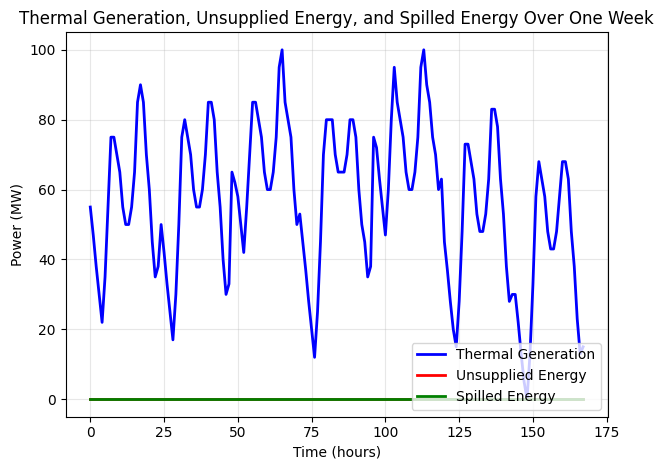

In [9]:
from gems.study.data import TimeScenarioIndex
import matplotlib.pyplot as plt

# Extract generation and nb_units_on data from results (which contains the solved values)
thermal_component = results.component("thermal_gen")
thermal_gen_data = thermal_component.var("generation")
unsupply_data = results.component("my_area").var("unsupplied_energy")
spilled_data = results.component("my_area").var("spillage") 

# Convert to lists using TimeScenarioIndex - use .get() to handle missing keys
thermal_gen_values = [thermal_gen_data._value.get(TimeScenarioIndex(i, 0), 0) for i in range(TimeSpan)]
unsupply_values = [unsupply_data._value.get(TimeScenarioIndex(i, 0), 0) for i in range(TimeSpan)]
spilled_values = [spilled_data._value.get(TimeScenarioIndex(i, 0), 0) for i in range(TimeSpan)]

# Plot Thermal generation, Unsupplied energy, and Spilled energy over time
plt.plot(thermal_gen_values, linewidth=2, markersize=4, color='blue', label='Thermal Generation')
plt.plot(unsupply_values, linewidth=2, markersize=4, color='red', label='Unsupplied Energy')
plt.plot(spilled_values, linewidth=2, markersize=4, color='green', label='Spilled Energy')
plt.xlabel('Time (hours)')
plt.ylabel('Power (MW)')
plt.title('Thermal Generation, Unsupplied Energy, and Spilled Energy Over One Week')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

By adding the renewable generation to the system, there is no more unsupplied energy.

In the next section, the thermal generator will have several units, forcing the system to implement unit commitment.

# Add Unit Commitment

## Add Units in the thermal cluster

We configure the **10 units** inside the thermal generator cluster.

For each unit :
* the minimum power generated is set to 1 MW
* the maximum power generated is set to 10 MW
* the startup cost is set to 20 €
* the fixed cost is set to 10 €

In [10]:
# Delete the previous thermal generator component
components = [comp for comp in components if comp.id != 'thermal_gen']

# Delete the previous connection between the area and the thermal generator
connections = [conn for conn in connections if not (conn.component2 == 'thermal_gen' or conn.component1 == 'thermal_gen')]


input_system = InputSystem(
    id = "my_system",
    components=components,
    connections=connections,
    )

# Uncomment the following lines to print the input system to verify the changes
# print("\tThe following input system has been created :")
# print(input_system)

In [ ]:
print("NEW COMPONENT DEFINITION")

# Create a new thermal generator with different parameters
components.append(
    InputComponent(
        id="thermal_gen_UC",
        model=f"{library_name}.thermal",
        parameters=[
            InputComponentParameter(id="p_min_unit", time_dependent=False, scenario_dependent=False, value=1),
            InputComponentParameter(id="p_max_unit", time_dependent=False, scenario_dependent=False, value=10),
            InputComponentParameter(id="p_max_cluster", time_dependent=False, scenario_dependent=False, value=100),
            InputComponentParameter(id="generation_cost", time_dependent=False, scenario_dependent=False, value=50),
            InputComponentParameter(id="startup_cost", time_dependent=False, scenario_dependent=False, value=20),
            InputComponentParameter(id="fixed_cost", time_dependent=False, scenario_dependent=False, value=10),
            InputComponentParameter(id="d_min_up", time_dependent=False, scenario_dependent=False, value=1),
            InputComponentParameter(id="d_min_down", time_dependent=False, scenario_dependent=False, value=1),
            InputComponentParameter(id="unit_count", time_dependent=False, scenario_dependent=False, value=10),
            InputComponentParameter(id="spinning", time_dependent=False, scenario_dependent=False, value=0),
            InputComponentParameter(id="minimum_generation_modulation", time_dependent=False, scenario_dependent=False, value=0),
        ],
    )
)

# Add connections
connections.append(
    InputPortConnections(
        component1="my_area",
        port1="balance_port",
        component2="thermal_gen_UC",
        port2="balance_port",
    )
)   

print("\tComponents defined:\n\t", [comp.id for comp in components])
print("\tConnections defined:")
for conn in connections:
    print(f"\t\t{conn.component1}:{conn.port1} <-> {conn.component2}:{conn.port2}")

input_system = InputSystem(
    id = "my_system",
    components=components,
    connections=connections,
    )   

## Results Visualization

In [12]:
print("OPTIMIZATION PROBLEM BUILDING")

result_lib = resolve_library(input_libraries)
components_input = resolve_system(input_system, result_lib)
database = build_data_base(input_system, Path(series_folder))

network = build_network(components_input)
problem = build_problem(
    network,
    database,
    TimeBlock(1, [i for i in range(0, TimeSpan)]),
    ScenarioNumber,
)


print("\t✓ Optimization problem built successfully")

print("SOLVING OPTIMIZATION PROBLEM")
try:
    status = problem.solver.Solve()
    objective_value = problem.solver.Objective().Value()
    print("\t✓ Optimization problem solved successfully")
    results = OutputValues(problem)
    print("\t✓ Results extracted successfully")
except Exception as e:
    print(f"Error solving optimization problem: {e}")
    raise e


# Printing results
objective_value = results.problem.solver.Objective().Value()
print(f"\t✓ Objective value: {objective_value}")

# Uncomment the following line to print the whole results
# print("\n","="*15," RESULTS ","="*15)
# print(results)

OPTIMIZATION PROBLEM BUILDING
	✓ Optimization problem built successfully
SOLVING OPTIMIZATION PROBLEM
	✓ Optimization problem solved successfully
	✓ Results extracted successfully
	✓ Objective value: 488990.0


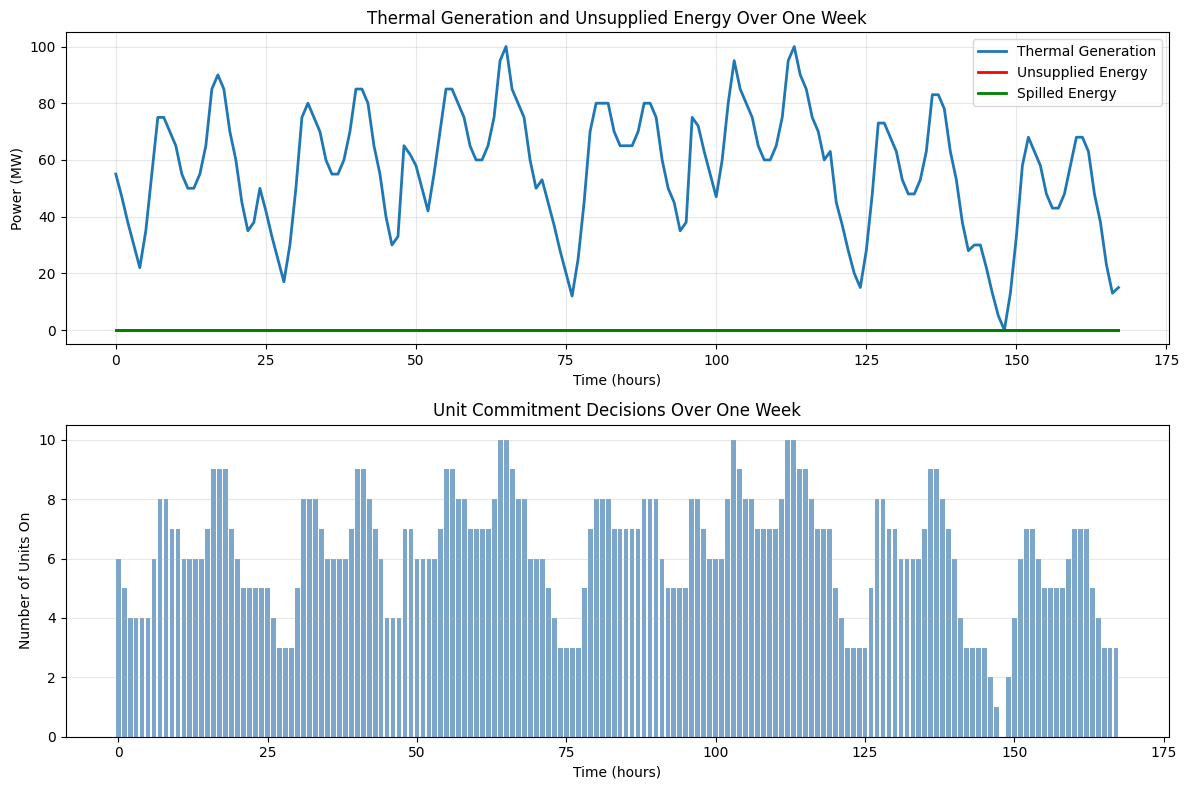

In [13]:
from gems.study.data import TimeScenarioIndex
import matplotlib.pyplot as plt

# Extract generation and nb_units_on data from results (which contains the solved values)
thermal_component = results.component("thermal_gen_UC")
thermal_gen_data = thermal_component.var("generation")
thermal_nb_units_data = thermal_component.var("nb_units_on")

unsupply_data = results.component("my_area").var("unsupplied_energy")
spilled_data = results.component("my_area").var("spillage")

# Convert to lists using TimeScenarioIndex - use .get() to handle missing keys
thermal_gen_values = [thermal_gen_data._value.get(TimeScenarioIndex(i, 0), 0) for i in range(TimeSpan)]
thermal_nb_units_values = [thermal_nb_units_data._value.get(TimeScenarioIndex(i, 0), 0) for i in range(TimeSpan)]
unsupply_values = [unsupply_data._value.get(TimeScenarioIndex(i, 0), 0) for i in range(TimeSpan)]
spilled_values = [spilled_data._value.get(TimeScenarioIndex(i, 0), 0) for i in range(TimeSpan)]

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Plot 1: Thermal generation over time
ax1.plot(thermal_gen_values, linewidth=2, markersize=4, label='Thermal Generation')
ax1.plot(unsupply_values, linewidth=2, markersize=4, color='red', label='Unsupplied Energy')
ax1.plot(spilled_values, linewidth=2, markersize=4, color='green', label='Spilled Energy')
ax1.set_xlabel('Time (hours)')
ax1.set_ylabel('Power (MW)')
ax1.set_title('Thermal Generation and Unsupplied Energy Over One Week')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Number of units on over time
ax2.bar(range(TimeSpan), thermal_nb_units_values, color='steelblue', alpha=0.7)
ax2.set_xlabel('Time (hours)')
ax2.set_ylabel('Number of Units On')
ax2.set_title('Unit Commitment Decisions Over One Week')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

The results illustrate how the number of thermal units generating power changes over the simulation week, reflecting the unit commitment feature. 

Indeed, the number of thermal units on fluctuated throughout the wind and solar power generation.